In [1]:
import numpy as np
import matplotlib.pyplot as plt
import logging
data = np.load("/pscratch/sd/k/kberard/SCGSR/EDDA/Data_Gen/plot_data/jsd_plot_data_full_range.npz", allow_pickle=True)

model_results_FFT = [tuple(x) for x in data["model_results_FFT"]]
results_array_ref = data["results_array_ref"]
models = list(data["models"])
DFT_vs_VMC = float(data["DFT_vs_VMC"])

results_dict = {m: data[f"results_{m}"] for m in models}  # each is an (N,2) array





In [2]:
# To load it back later
loaded_data = np.load('/pscratch/sd/k/kberard/SCGSR/EDDA/Data_Gen/plot_data/JSD_data.npy', allow_pickle=True).item()
print(loaded_data.keys())

dict_keys(['scunet_pre', 'bm3d'])


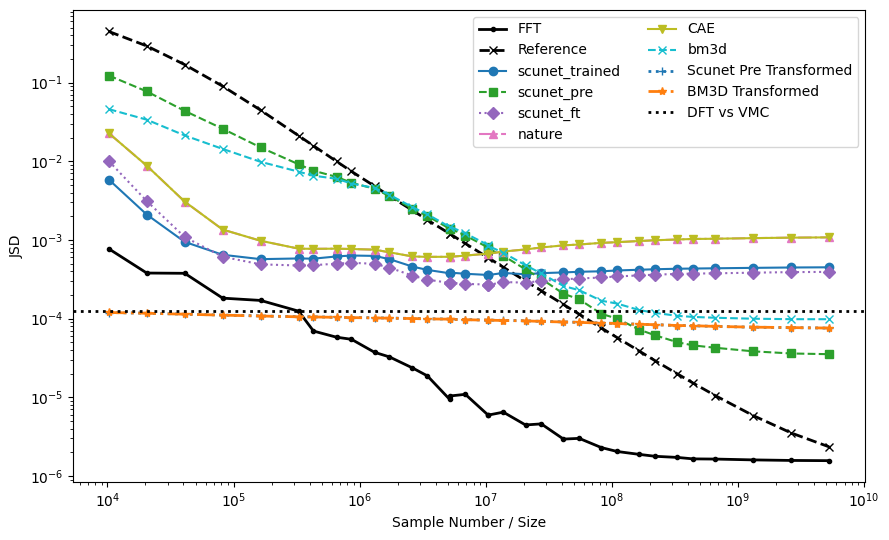

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import logging

logging.getLogger('matplotlib').setLevel(logging.WARNING)

plt.figure(figsize=(9, 5.5))

# ---------------- Style pools ----------------
markers = ["o", "s", "D", "^", "v", "x", "+", "*", "P", "<", ">"]
linestyles = ["-", "--", ":", "-."]

marker_idx = 0
line_idx = 0

# ---------------- FFT ----------------
x_fft, y_fft = zip(*model_results_FFT)
plt.loglog(
    x_fft,
    y_fft,
    marker=".",
    linestyle="-",
    color="black",
    linewidth=2,
    label="FFT",
)

# ---------------- Reference ----------------
plt.loglog(
    results_array_ref[:, 0],
    results_array_ref[:, 1],
    marker="x",
    linestyle="--",
    color="black",
    linewidth=2,
    label="Reference",
)

# ---------------- Main ML models ----------------
colors = plt.cm.tab10(np.linspace(0, 1, len(models)))

for color, model_name in zip(colors, models):
    results_array = results_dict[model_name]
    results_array = results_array[np.argsort(results_array[:, 0])]

    plt.loglog(
        results_array[:, 0],
        results_array[:, 1],
        marker=markers[marker_idx % len(markers)],
        linestyle=linestyles[line_idx % len(linestyles)],
        color=color,
        label=model_name,
    )

    marker_idx += 1
    line_idx += 1

# ---------------- Transformed methods (from loaded_data) ----------------
for method, values in loaded_data.items():
    x = np.array([v[0] for v in values])
    y = np.array([v[1] for v in values])

    label = (
        "Scunet Pre Transformed"
        if method == "scunet_pre"
        else "BM3D Transformed"
    )

    plt.loglog(
        x,
        y,
        marker=markers[marker_idx % len(markers)],
        linestyle=linestyles[line_idx % len(linestyles)],
        linewidth=2,
        label=label,
    )

    marker_idx += 1
    line_idx += 1

# ---------------- DFT vs VMC line ----------------
plt.axhline(
    DFT_vs_VMC,
    color="black",
    linestyle=":",
    linewidth=2,
    label="DFT vs VMC",
)


# ---------------- Decorations ----------------
plt.xlabel("Sample Number / Size")
plt.ylabel("JSD")
plt.legend(ncol=2)
plt.tight_layout()
plt.show()
